# **Procesamiento de Lenguaje Natural**: Vectorizacion de documentos. Agrupamiento.


**Vanessa Gómez Verdejo, Emilio Parrado Hernández,  Pablo Martínez Olmos, Angel Navia Vázquez**

  * v1.1 (January 2026) Revised and updated version

Departamento de Teoría de la Señal y Comunicaciones

**Universidad Carlos III de Madrid**

<img src='http://www.tsc.uc3m.es/~navia/figures/logo_uc3m_foot.jpg' width=400 />


In [1]:
# Ejecutamos este código para preparar el contexto.
%matplotlib inline
# Figures plotted inside the notebook
%config InlineBackend.figure_format = 'svg'
# High quality figures
import matplotlib.pyplot as plt

In [2]:
# Estas librerías pueden dar problemas de dependencias, conviene instalarlas conjuntamente, para que pip resuelva correctamente las dependencias
!pip install --upgrade numpy pandas scipy gensim spacy nltk

In [3]:
import sys
!{sys.executable} -m pip install --upgrade --force-reinstall --no-cache-dir \
numpy==2.4.2 scipy==1.17.0 pandas==3.0.0 spacy==3.8.11 gensim==4.4.0 nltk==3.9.2 scikit-learn==1.6.1



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 12.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.1/20.1 MB 12.5 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 15.9 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 16.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 16.7 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 22.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 11.3 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 19.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 653.1/653.1 kB 19.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 770.6/770.6 kB 3.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 15.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━

In [4]:
import sys
!{sys.executable} -m pip install -U --force-reinstall --no-cache-dir \
"numpy==2.4.2" "scipy==1.17.0" "pandas==3.0.0" "spacy==3.8.11" "gensim==4.4.0" "nltk==3.9.2" "scikit-learn==1.6.1" \
-U matplotlib contourpy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 22.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.1/20.1 MB 15.7 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 9.3 MB/s  0:00:01 eta 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 16.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 13.5 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 27.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 15.0 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 13.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 653.1/653.1 kB 10.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 770.6/770.6 kB 21.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 10.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━

In [5]:
import numpy as np
import scipy
import pandas as pd
import spacy
import gensim
import nltk
import sklearn

print(f"NumPy version: {np.__version__}")
print(f"Scipy version: {scipy.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Spacy version: {spacy.__version__}")
print(f"Gensim version: {gensim.__version__}")
print(f"NLTK version: {nltk.__version__}")
print(f"Sklearn version: {sklearn.__version__}")

# 2025:
# NumPy version: 1.26.4
# Scipy version: 1.13.1
# Pandas version: 2.2.3
# Spacy version: 3.8.4
# Gensim version: 4.3.3
# NLTK version: 3.9.1
# Sklearn version: 1.6.1

# 2026:
# NumPy version: 2.4.2
# Scipy version: 1.17.0
# Pandas version: 3.0.0
# Spacy version: 3.8.11
# Gensim version: 4.4.0
# NLTK version: 3.9.2
# Sklearn version: 1.6.1

NumPy version: 2.4.2
Scipy version: 1.17.0
Pandas version: 3.0.0
Spacy version: 3.8.11
Gensim version: 4.4.0
NLTK version: 3.9.2
Sklearn version: 1.6.1


# 1 - Repaso: preprocesado de un corpus

En este notebook vamos a aprender a usar la **librería** [**Gensim**](https://radimrehurek.com/gensim/) para construir un vocabulario en base a nuestro corpus de documentos y **vectorizar** cada uno de ellos (representarlos mediante un vector de números reales), representación que ya es susceptible de combinarse con algoritmos de aprendizaje automático tales como agrupación y clasificación.

Para empezar a trabajar vamos a usar el corpus **inaugural**, uno de los corpus de datos incluidos en NLTK y que consiste en 58 documentos de texto con los discursos presidenciales de los presidentes de EEUU.

La siguiente celda de código nos muestra cómo cargar el corpus.

In [6]:
from nltk.corpus import inaugural
nltk.download('inaugural')

[nltk_data] Downloading package inaugural to
[nltk_data]     /Users/matveypro/nltk_data...
[nltk_data]   Unzipping corpora/inaugural.zip.


True

In [7]:
print('The "Inaugural" corpus has {} documents.'.format(len(inaugural.fileids())))

The "Inaugural" corpus has 60 documents.


Recordemos el uso de los métodos **`fileids`** y **`raw`**:

In [8]:
first_id = list(inaugural.fileids())[0]
print("Este es el identificador del primer documento: {}".format(first_id))

print("\nEste es el texto de dicho documento:\n")
text = inaugural.raw(first_id)
print("-" * 50)
print(text)
print("-" * 50)

Este es el identificador del primer documento: 1789-Washington.txt

Este es el texto de dicho documento:

--------------------------------------------------
Fellow-Citizens of the Senate and of the House of Representatives:

Among the vicissitudes incident to life no event could have filled me with greater anxieties than that of which the notification was transmitted by your order, and received on the 14th day of the present month. On the one hand, I was summoned by my Country, whose voice I can never hear but with veneration and love, from a retreat which I had chosen with the fondest predilection, and, in my flattering hopes, with an immutable decision, as the asylum of my declining years -- a retreat which was rendered every day more necessary as well as more dear to me by the addition of habit to inclination, and of frequent interruptions in my health to the gradual waste committed on it by time. On the other hand, the magnitude and difficulty of the trust to which the voice of my 

In [10]:
import sys
!{sys.executable} -m spacy download en_core_web_sm
import spacy
nlp_spacy = spacy.load("en_core_web_sm")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 21.2 MB/s  0:00:00m0:00:010:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [11]:
# Descargamos el modelo Spacy y procesamos este texto

# Cargamos el modelo
nlp_spacy = spacy.load("en_core_web_sm")

In [12]:
# Procesamos el texto
text_spacy = nlp_spacy(text)
print(type(text_spacy))

<class 'spacy.tokens.doc.Doc'>


 ## **Ejercicio**:

 Cargue la función de normalizado de texto implementada en la sesión anterior y construya `corpus_prec`, una lista con cada uno de los documentos del corpus `inaugural` preprocesados (cada texto debe convertirse en una lista de tokens).

In [ ]:
# We define a normalization function
def normalize_Spacy(text):
    <INSERT CODE HERE>
    return normalized_text

# We test the normalization function
text = "This is an examPLE OF NORMalization!!!. We normalize text by extracting lemmas, remove stop words (and punctuation siymbols), and also lower case the words ."
print(normalize_Spacy(text))

In [ ]:
# Preprocessing the whole corpus, we obtain a list of lists of tokens
corpus_prec = <INSERT CODE HERE>
print('\nEl corpus preprocesado contiene {} documentos.'.format(len(corpus_prec)))

In [ ]:
print('\nEl corpus preprocesado contiene {} documentos.'.format(len(corpus_prec)))
print('\nEl corpus procesado es una lista de listas, conteniendo tokens:')
print(type(corpus_prec))
print(type(corpus_prec[0]))
print(type(corpus_prec[0][0]))

## Solución:

In [13]:
# We define a normalization function
def normalize_Spacy(text):
    text2 = nlp_spacy(text)
    normalized_text = [w.lemma_.lower() for w in text2 if not w.is_stop
                  and not w.is_punct and (w.is_alpha or w.is_digit)]
    return normalized_text

# We test the normalization function
text = "This is an examPLE OF NORMalization!!!. We normalize text by extracting lemmas, remove stop words (and punctuation siymbols), and also lower case the words ."
print(normalize_Spacy(text))

['example', 'normalization', 'normalize', 'text', 'extract', 'lemma', 'remove', 'stop', 'word', 'punctuation', 'siymbol', 'low', 'case', 'word']


In [14]:
# Preprocessing the whole corpus, we obtain a list of lists of tokens
corpus_prec = [normalize_Spacy(inaugural.raw(file)) for file in inaugural.fileids()]


In [15]:
print('\nEl corpus preprocesado contiene {} documentos.'.format(len(corpus_prec)))
print('\nEl corpus procesado es una lista de listas, conteniendo tokens:')
print(type(corpus_prec))
print(type(corpus_prec[0]))
print(type(corpus_prec[0][0]))


El corpus preprocesado contiene 60 documentos.

El corpus procesado es una lista de listas, conteniendo tokens:
<class 'list'>
<class 'list'>
<class 'str'>


El siguiente código muestra los 20 primeros tokens de los tres primeros documentos del corpus preprocesado:

In [16]:
print(50 * "-")
print('Algunos tokens del primer documento preprocesado')
print(corpus_prec[0][:20])
print(50 * "-")
print('Algunos tokens del segundo documento preprocesado')
print(corpus_prec[1][:20])
print(50 * "-")
print('Algunos tokens del tercer documento preprocesado')
print(corpus_prec[3][:20])

--------------------------------------------------
Algunos tokens del primer documento preprocesado
['fellow', 'citizen', 'senate', 'house', 'representatives', 'vicissitude', 'incident', 'life', 'event', 'fill', 'great', 'anxiety', 'notification', 'transmit', 'order', 'receive', 'day', 'present', 'month', 'hand']
--------------------------------------------------
Algunos tokens del segundo documento preprocesado
['fellow', 'citizen', 'call', 'voice', 'country', 'execute', 'function', 'chief', 'magistrate', 'occasion', 'proper', 'shall', 'arrive', 'shall', 'endeavor', 'express', 'high', 'sense', 'entertain', 'distinguished']
--------------------------------------------------
Algunos tokens del tercer documento preprocesado
['friend', 'fellow', 'citizens', 'call', 'undertake', 'duty', 'executive', 'office', 'country', 'avail', 'presence', 'portion', 'fellow', 'citizen', 'assemble', 'express', 'grateful', 'thank', 'favor', 'pleased']



# 2 - Bag of Words (BOW)

Esta parametrización de textos consiste en el **conteo de la ocurrencia de palabras por documento** es lo que se conoce como **bag-of-words** (bolsa de palabras) o, de manera abreviada como , **BoW**. En concreto, **bag-of-words** es una representación de un texto de tal forma que éste queda descrito por las veces que aparece cada palabra del vocabulario en dicho texto.

Se llama "bolsa" de palabras, porque **cualquier información sobre el orden o la estructura de las palabras en el documento es descartada**. El modelo sólo tiene en cuenta si las palabras del vocabulario aparecen en el documento, no su ubicación en el documento.

Para obtener la representación BoW podemos utilizar varias librerías alternativas. Por un lado, **`Sklearn` incluye funcionalidades para el análisis de texto**, y podrían valernos para el mismo fin las propias funcionalidades de **NLTK para el conteo de palabras o análisis frecuencial**. Sin embargo, en esta sección vamos a ver cómo usar la librería de [**`Gensim`**](https://pypi.org/project/gensim/) diseñada específicamente para el procesado de texto, permitiendo un procesado muy eficiente para grandes corpus e incluyendo funcionalides adicionales de gran utilidad.

El proceso de **generación del BoW con Gensim** tiene dos pasos:

1. **Generación/adaptación del vocabulario** del corpus mediante un **vocabulario** que almacena de manera ordenada una lista de palabras conocidas (a nivel de corpus). **El tamaño del vocabulario influirá directamente en el tamaño de las parametrizaciones BOW**.

2. **Vectorización de documentos** o generación del BoW. Se calcula una medida de la presencia de palabras conocidas (las que están en el vocabulario); para ello, realiza  un **conteo del número de veces que cada palabra del vocabulario aparece dentro de cada documento**.

Veamos a continuación, como implementar estos pasos:


## 2.1 - Generación del vocabulario con Gensim

Utilizaremos, como hemos comentado, la librería gensim.

In [17]:
n_docs = len(corpus_prec)

# Create vocabulary of tokens: the input is the preprocessed corpus (list of docs, each doc is a list of tokens)
Vocab = gensim.corpora.Dictionary(corpus_prec)
print("Cada uno de los elementos del vocabulario es un string:")
print(type(Vocab))
print(type(Vocab[0]))

n_tokens = len(Vocab)
print('The vocabulary contains {} terms.'.format(n_tokens))

print('\nThe first terms in the vocabulary are:')
for n in range(5):
    print(str(n), ':', Vocab[n])

print('\nThe last terms in the vocabulary are:')
for n in range(n_tokens-5, n_tokens):
    print(str(n), ':', Vocab[n])

Cada uno de los elementos del vocabulario es un string:
<class 'gensim.corpora.dictionary.Dictionary'>
<class 'str'>
The vocabulary contains 6650 terms.

The first terms in the vocabulary are:
0 : accomplish
1 : accordingly
2 : acknowledge
3 : acquit
4 : act

The last terms in the vocabulary are:
6645 : verge
6646 : weaponization
6647 : weaponize
6648 : william
6649 : wow


Como vemos el **vocabulario no es más que una lista (ordenada) de palabras**. Pero **el orden y contenidos de esta lista será muy importante** para la vectorización de cada documento, ya que generaremos tuplas de (`id`, `conteo`) y los `id` serán las posiciones de estas palabras en el vocabulario.

**IMPORTANTE**: fijémonos que el vocabulario se crea a partir del corpus (total de documentos). Cualquier alteración del corpus (añadir o eliminar documentos) podría implicar una modificación del vocabulario y por tanto parametrizaciones previas ya no serían válidas, al cambiar las posiciones de las palabras en el vocabulario.

Si queremos conocer el **`id` asociado a un token en particular**, utilizaremos el método del vocabulario **`token2id`**:

In [19]:
print('El id correspondiente al token "president" es {}.'.format(Vocab.token2id["president"]))

El id correspondiente al token "president" es 321.


Podemos usar el método **`get`** para obtener el `id` correspondiente a una palabra o `None` si esta no pertenece al diccionario (evita errores de ejecución). Observe la diferencia entre estos dos códigos:

In [18]:
print(Vocab.token2id.get("president"))
print(Vocab.token2id.get("dsañljfasd"))

321
None


Las siguientes **propiedades asociadas al vocabulario** son también muy importantes y útiles, se **calculan automáticamente** al generar el vocabulario y son **diccionarios python indexados por el índice de cada palabra en el vocabulario**:

-  **`cfs`**: cuenta el número de veces que **una palabra aparece en todo el corpus**

- **`dfs`** cuenta el **número de documentos en los que dicha palabra está presente**

Veamos un ejemplo:

In [20]:
id = Vocab.token2id.get("president")  # id de la palabra en el vocabulario
print("The term 'president' is mentioned {} times in all documents, and is present in {} of them.".format(Vocab.cfs[id], Vocab.dfs[id]))

id = Vocab.token2id.get("citizen")    # id de la palabra en el vocabulario
print("The term 'citizen' is mentioned {} times in all documents, and is present in {} of them.".format(Vocab.cfs[id], Vocab.dfs[id]))

The term 'president' is mentioned 108 times in all documents, and is present in 38 of them.
The term 'citizen' is mentioned 309 times in all documents, and is present in 56 of them.


## 2.2 - Gestión del Vocabulario

**Cuanto mayor es el tamaño del vocabulario, más grande es la representación vectorial de los documentos**.

Para un corpus muy grande y variado, **la longitud del vector que representará cada documento puede ser de miles o incluso millones de posiciones**, lo cual representa un problema para los procesados posteriores.

**NOTA:** Tenga en cuenta que si no ha habido un filtrado previo, los elementos de un vocabulario no tienen por que ser simplemente palabras, por ejemplo, podrían estar incluidos signos, caracteres especiales, puntuaciones, números, etc.  

Para reducir este problema, es recomendable **analizar el vocabulario y eliminar tokens que no resulten relevantes**:

- **marcas de puntuación o caracteres especiales**

- **tokens numéricos** poco informativos

- **términos que aparecen en muy pocos documentos** (por lo que no son muy relevantes para el conjunto del corpus)

- **términos que figuran en casi todos los documentos del corpus** (y por tanto no aportan mucha información al no ser discriminativos).

El vocabulario de Gensim nos permite filtrar estos términos fácilmente:

* **`filter_tokens`** nos permite indicar con el parámetro `bad_ids` la lista de ids de las **palabras a eliminar** o con `good_ids` la lista de los ids de las **palabras a dejar** en el vocabulario (eliminando el resto).

* **`filter_extremes`** permite **eliminar palabras/tokens poco o muy frecuentes** en los documentos indicando con los parámetros:
  * **`no_below`**: se queda con los **tokens que están contenidas en al menos `no_below` documentos**.
  * **`no_above`** (fracción del tamaño total del corpus, no un número absoluto): retiene los tokens que no están en más de una fracción `no_above` de los documentos.
  * **`keep_n`**: se queda exactamente con los `keep_n` tokens más relevantes, **eliminando los más y menos frecuentes**.
  * **`keep_tokens`**: listado de **tokens que deben permanecer en el vocabulario** después de ser filtradas.

**Nota:** Tras utilizar este filtrado, se habran eliminado algunos ids, y puede que la lista de ids ya no sea consecutiva. Asimismo el id de una determinada palabra también puede haber cambiado.

 Veamos como probar estas dos funcionalidades. Para ello, en primer lugar, veamos cómo eliminar algunas palabras individuales del vocabulario.

In [21]:
# We can filter out specific terms, for example: accomplish, accordingly, virus
id1 = Vocab.token2id.get("accomplish")
print('The corresponding id of token "accomplish" is {}.'.format(id1))
id2 = Vocab.token2id.get("accordingly")
print('The corresponding id of token "accordingly" is {}.'.format(id2))
id3 = Vocab.token2id.get("virus")
print('The corresponding id of token "virus" is {}.'.format(id3))

n_tokens = len(Vocab)
print('\nThe vocabulary contains {} terms before filtering.'.format(n_tokens))

Vocab.filter_tokens(bad_ids=[id1, id2, id3])
n_tokens = len(Vocab)
print('The vocabulary contains {} terms after filtering.'.format(n_tokens))
print('\nWe can verify that the terms have been removed from the vocabulary:')
print(Vocab.token2id.get("accomplish"))
print(Vocab.token2id.get("accordingly"))
print(Vocab.token2id.get("virus"))


The corresponding id of token "accomplish" is 0.
The corresponding id of token "accordingly" is 1.
The corresponding id of token "virus" is 6555.

The vocabulary contains 6650 terms before filtering.
The vocabulary contains 6647 terms after filtering.

We can verify that the terms have been removed from the vocabulary:
None
None
None


A continuación vamos a eliminar las palabras según su **frecuencia de aparición en los documentos**.

In [22]:
# Calculamos de nuevo el vocabulario, pues lo hemos alterado con las pruebas anteriores.
Vocab = gensim.corpora.Dictionary(corpus_prec)
n_tokens = len(Vocab)
print('El vocabulary tiene {} palabras.'.format(n_tokens))

apariciones = [(id, Vocab.cfs[id]) for id in range(len(Vocab))]
apariciones.sort(key=lambda x:x[1], reverse=True)
print('\nPalabras que más aparecen en total (palabra , conteo):')
for pair in apariciones[0:5]:
  print(Vocab[pair[0]], '\t\t', pair[1])

print('\nPalabras que menos aparecen en total (palabra , conteo):')
apariciones.sort(key=lambda x:x[1], reverse=False)
for pair in apariciones[0:5]:
  print(Vocab[pair[0]], '\t\t', pair[1])

apariciones = [(id, Vocab.dfs[id]) for id in range(len(Vocab))]
apariciones.sort(key=lambda x:x[1], reverse=True)
print('\nPalabras que aparecen en mayor fracción de documentos (palabra , fracción de documentos):')
for pair in apariciones[0:5]:
  print(Vocab[pair[0]], '\t\t', pair[1]/n_docs)

apariciones.sort(key=lambda x:x[1], reverse=False)
print('\nPalabras que aparecen en menor número de documentos (palabra, fracción de documentos, (número de documentos)):')
for pair in apariciones[0:5]:
  print(Vocab[pair[0]], '\t\t', pair[1]/n_docs, "(", pair[1], ")")


El vocabulary tiene 6650 palabras.

Palabras que más aparecen en total (palabra , conteo):
government 		 661
people 		 641
nation 		 535
great 		 457
country 		 375

Palabras que menos aparecen en total (palabra , conteo):
acquit 		 1
asylum 		 1
auspiciously 		 1
aver 		 1
characteristic 		 1

Palabras que aparecen en mayor fracción de documentos (palabra , fracción de documentos):
great 		 0.9666666666666667
nation 		 0.9666666666666667
people 		 0.9666666666666667
country 		 0.95
citizen 		 0.9333333333333333

Palabras que aparecen en menor número de documentos (palabra, fracción de documentos, (número de documentos)):
acquit 		 0.016666666666666666 ( 1 )
asylum 		 0.016666666666666666 ( 1 )
auspiciously 		 0.016666666666666666 ( 1 )
aver 		 0.016666666666666666 ( 1 )
characteristic 		 0.016666666666666666 ( 1 )


In [23]:
no_below = 10 # Minimum NUMBER of DOCUMENTS to keep a term in the vocabulary
no_above = .85 # Maximum PROPORTION of DOCUMENTS in which a term can appear to be kept in the vocabulary

print('El vocabulario tiene {} palabras.'.format(n_tokens))
print('Filtramos los extremos...')

# Filtrado del vocabulario
Vocab.filter_extremes(no_below=no_below, no_above=no_above)

n_tokens = len(Vocab)
print('El vocabulario tiene ahora {} palabras.'.format(n_tokens))



El vocabulario tiene 6650 palabras.
Filtramos los extremos...
El vocabulario tiene ahora 957 palabras.


In [24]:
print('Limitamos ahora el número total de elementos del vocabulario...')
Vocab.filter_extremes(keep_n = 500)
n_tokens = len(Vocab)
print('El vocabulario tiene ahora {} palabras.'.format(n_tokens))

Limitamos ahora el número total de elementos del vocabulario...
El vocabulario tiene ahora 500 palabras.


**Nota:** los dos pasos anteriores se pueden hacer de una sola vez, pasando los tres argumentos a D.filter_extremes()

Esto elimina todas los tokens en el vocabulario que:

1. Aparecen en menos de 10 documentos (`no_below = 10`).

2. Aparecen en más del 85% de los documentos (`no_above = 0.85`).

3. Después de aplicar (1) y (2), retiene los 500 tokens más frecuentes (`keep_n = 500`). Este valor define el tamaño final del vocabulario.

Veamos las estadísticas tras este filtrado:


In [25]:
apariciones = [(id, Vocab.cfs[id]) for id in range(len(Vocab))]
apariciones.sort(key=lambda x:x[1], reverse=True)
print('Palabras que más aparecen en total (palabra - conteo):')
for pair in apariciones[0:5]:
  print(Vocab[pair[0]], '\t\t', pair[1])

print('\nPalabras que menos aparecen en total (palabra - conteo):')
apariciones.sort(key=lambda x:x[1], reverse=False)
for pair in apariciones[0:5]:
  print(Vocab[pair[0]], '\t\t', pair[1])

apariciones = [(id, Vocab.dfs[id]) for id in range(len(Vocab))]
apariciones.sort(key=lambda x:x[1], reverse=True)
print('\nPalabras que aparecen en mayor fracción de documentos (palabra - fracción de documentos):')
for pair in apariciones[0:5]:
  print(Vocab[pair[0]], '\t\t', pair[1]/n_docs)

apariciones.sort(key=lambda x:x[1], reverse=False)
print('\nPalabras que aparecen en menor número de documentos (palabra, fracción de documentos, (número de documentos)):')
for pair in apariciones[0:5]:
  print(Vocab[pair[0]], '\t\t', pair[1]/n_docs, "(", pair[1], ")")

Palabras que más aparecen en total (palabra - conteo):
congress 		 130
today 		 122
executive 		 99
institution 		 89
americans 		 88

Palabras que menos aparecen en total (palabra - conteo):
anxiety 		 15
disposition 		 15
grateful 		 15
justly 		 15
divine 		 16

Palabras que aparecen en mayor fracción de documentos (palabra - fracción de documentos):
mind 		 0.5
opportunity 		 0.5
like 		 0.5
ask 		 0.5
generation 		 0.5

Palabras que aparecen en menor número de documentos (palabra, fracción de documentos, (número de documentos)):
acknowledge 		 0.23333333333333334 ( 14 )
anxiety 		 0.23333333333333334 ( 14 )
birth 		 0.23333333333333334 ( 14 )
disposition 		 0.23333333333333334 ( 14 )
equally 		 0.23333333333333334 ( 14 )


## 2.3 - Visualización del vocabulario de nuestro corpus

A continuación, vamos a volver a generar el vocabulario de nuestro corpus y visualizar las frecuencias de aparición de las palabras iniciales y tras aplicar las funciones de filtrado anteriores para reducir el vocabulario (`Vocab.filter_extremes()`).

Para la visualización necesitaremos las propiedades de la clase vocabulario de gensim `dfs` (calcula en cuántos documentos del corpus aparece cada palabra del vocabulario) y `cfs` (calcula cuántas veces aparece cada palabra del vocabulario en todo el corpus). Puede ver la ayuda en este [link](https://radimrehurek.com/gensim/corpora/dictionary.html).

A modo de recordatorio, vamos a resolver una serie de ejercicios previos:  

## Ejercicio:

Recalcule el vocabulario del corpus.

In [26]:
# Recompute the vocabulary
Vocab = gensim.corpora.Dictionary(corpus_prec)
n_tokens = len(Vocab)
print('El vocabulario tiene {} palabras.'.format(n_tokens))

El vocabulario tiene 6650 palabras.


## Solution

In [27]:
# Recompute the vocabulary
Vocab = gensim.corpora.Dictionary(corpus_prec)
n_tokens = len(Vocab)
print('El vocabulario tiene {} palabras.'.format(n_tokens))

El vocabulario tiene 6650 palabras.


## Ejercicio:

Muestre el número de documentos en los que aparecen los tokens `president`, `america`, `war`.

In [28]:
list_of_words = ['president','america','war']

n_doc_l = [Vocab.dfs[Vocab.token2id.get(token)] for token in list_of_words]

for i in range(3):
  print("La palabra '{}' aparece en {} documentos.' ".format(list_of_words[i], n_doc_l[i]))

La palabra 'president' aparece en 38 documentos.' 
La palabra 'america' aparece en 33 documentos.' 
La palabra 'war' aparece en 48 documentos.' 


## Solution

In [ ]:
list_of_words = ['president','america','war']

n_doc_l = [Vocab.dfs[Vocab.token2id.get(token)] for token in list_of_words]

for i in range(3):
  print("La palabra '{}' aparece en {} documentos.' ".format(list_of_words[i], n_doc_l[i]))


## Ejercicio:

Muestre el número de veces que aparecen en todo el corpus los tokens president, america, war.

In [29]:
n_veces_l = [Vocab.cfs[Vocab.token2id.get(token)] for token in list_of_words]

for i in range(3):
  print("La palabra '{}' aparece {} veces en todo el corpus.' ".format(list_of_words[i], n_veces_l[i]))

La palabra 'president' aparece 108 veces en todo el corpus.' 
La palabra 'america' aparece 250 veces en todo el corpus.' 
La palabra 'war' aparece 211 veces en todo el corpus.' 


## Solution

In [30]:
n_veces_l = [Vocab.cfs[Vocab.token2id.get(token)] for token in list_of_words]

for i in range(3):
  print("La palabra '{}' aparece {} veces en todo el corpus.' ".format(list_of_words[i], n_veces_l[i]))

La palabra 'president' aparece 108 veces en todo el corpus.' 
La palabra 'america' aparece 250 veces en todo el corpus.' 
La palabra 'war' aparece 211 veces en todo el corpus.' 


## Ejercicio:

Cree una lista con el número de documentos en los que aparecen cada uno de los términos del vocabulario. Ordene de mayor a menor y visualice el resultado.

Se debería poder observar que hay algunas palabras que aparecen en la casi totalidad de los documentos. Por otra parte, hay un buen número de palabras que aparecen en muy pocos documentos.

Muestre en pantalla los valores máximos y mínimos de este conteo.

¿Cuál es el máximo valor que puede tomar esta curva?

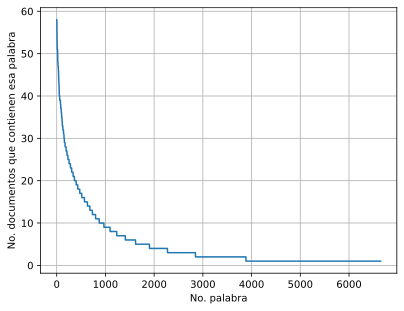

El máximo número de documentos en el que aparece una palabra es 58 y el mínimo es 1


In [31]:
n_docs_with_word = list(Vocab.dfs.values())
n_docs_with_word.sort(reverse=True)
plt.plot(n_docs_with_word)
plt.grid()
plt.xlabel('No. palabra')
plt.ylabel('No. documentos que contienen esa palabra')
plt.show()

print("El máximo número de documentos en el que aparece una palabra es {} y el mínimo es {}".format(n_docs_with_word[0], n_docs_with_word[-1]))

## Solution

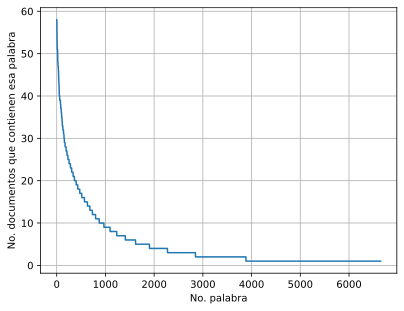

El máximo número de documentos en el que aparece una palabra es 58 y el mínimo es 1


In [32]:
n_docs_with_word = list(Vocab.dfs.values())
n_docs_with_word.sort(reverse=True)
plt.plot(n_docs_with_word)
plt.grid()
plt.xlabel('No. palabra')
plt.ylabel('No. documentos que contienen esa palabra')
plt.show()

print("El máximo número de documentos en el que aparece una palabra es {} y el mínimo es {}".format(n_docs_with_word[0], n_docs_with_word[-1]))

## Ejercicio:

Cree una lista con el número de veces que aparece cada uno de los términos del vocabulario en todo el corpus. Ordene de mayor a menor y visualice el resultado.

Debería obtenerse que hay palabras que aparecen muchas veces y por otro lado, muchas otras sólo aparecen una o dos veces.

¿Esta curva está acotada por algún valor?


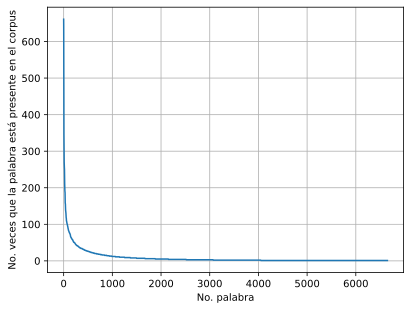

El máximo número total de veces que aparece una palabra es 661 y el mínimo es 1


In [33]:
conteo_palabras = list(Vocab.cfs.values())
conteo_palabras.sort(reverse=True)
plt.plot(conteo_palabras)
plt.grid()
plt.xlabel('No. palabra')
plt.ylabel('No. veces que la palabra está presente en el corpus')
plt.show()

print("El máximo número total de veces que aparece una palabra es {} y el mínimo es {}".format(conteo_palabras[0], conteo_palabras[-1]))


## Solution

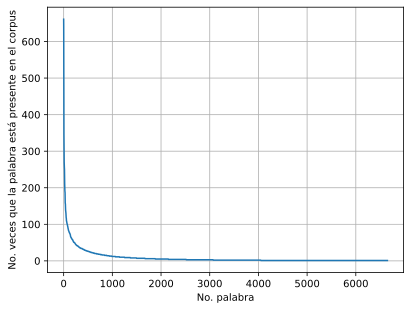

El máximo número total de veces que aparece una palabra es 661 y el mínimo es 1


In [34]:
conteo_palabras = list(Vocab.cfs.values())
conteo_palabras.sort(reverse=True)
plt.plot(conteo_palabras)
plt.grid()
plt.xlabel('No. palabra')
plt.ylabel('No. veces que la palabra está presente en el corpus')
plt.show()

print("El máximo número total de veces que aparece una palabra es {} y el mínimo es {}".format(conteo_palabras[0], conteo_palabras[-1]))


## Ejercicio:

Excluya del vocabulario todas las palabras que no estén en al menos 10 documentos y aquellas que estén en el 67.8% de los documentos.

Vuelva a representas las gráficas del apartado anterior y compare los resultados.

¿En cuántos documentos como mínimo puede aparecer ahora cada palabra?

¿En cuántos documentos como máximo puede aparecer ahora cada palabra?

In [35]:
no_below = 10 #Minimum number of documents to keep a term in the vocabulary
no_above = 0.678 #Maximum proportion of documents in which a term can appear to be kept in the vocabulary

Vocab.filter_extremes(no_below=no_below, no_above=no_above)
n_tokens = len(Vocab)
print('El vocabulario tiene ahora {} palabras.'.format(n_tokens))

El vocabulario tiene ahora 914 palabras.


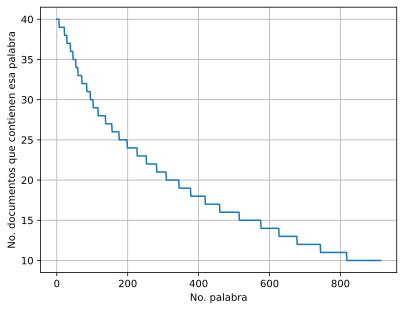

El máximo número de documentos en el que aparece una palabra es 40 y el mínimo es 10


In [37]:
# Visualizamos
n_docs_with_word = list(Vocab.dfs.values())
n_docs_with_word.sort(reverse=True)
plt.plot(n_docs_with_word)
plt.grid()
plt.xlabel('No. palabra')
plt.ylabel('No. documentos que contienen esa palabra')
plt.show()

print("El máximo número de documentos en el que aparece una palabra es {} y el mínimo es {}".format(n_docs_with_word[0], n_docs_with_word[-1]))

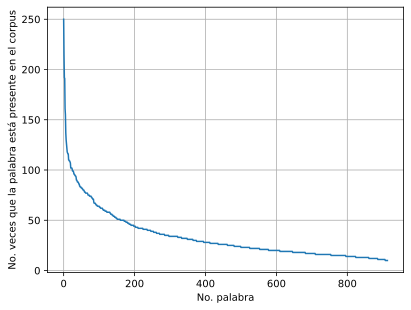

El máximo número total de veces que aparece una palabra es 250 y el mínimo es 10


In [38]:
conteo_palabras = list(Vocab.cfs.values())
conteo_palabras.sort(reverse=True)
plt.plot(conteo_palabras)
plt.grid()
plt.xlabel('No. palabra')
plt.ylabel('No. veces que la palabra está presente en el corpus')
plt.show()

print("El máximo número total de veces que aparece una palabra es {} y el mínimo es {}".format(conteo_palabras[0], conteo_palabras[-1]))


## Solution

In [36]:
no_below = 10 # Minimum number of documents to keep a term in the vocabulary
no_above = .678 # Maximum proportion of documents in which a term can appear to be kept in the vocabulary

Vocab.filter_extremes(no_below=no_below,no_above=no_above)
n_tokens = len(Vocab)
print('El vocabulario tiene ahora {} palabras.'.format(n_tokens))

El vocabulario tiene ahora 914 palabras.


In [ ]:
n_docs_with_word = list(Vocab.dfs.values())
n_docs_with_word.sort(reverse=True)
plt.plot(n_docs_with_word)
plt.grid()
plt.xlabel('No. palabra')
plt.ylabel('No. documentos que contienen esa palabra')
plt.show()

print("El máximo número de documentos en el que aparece una palabra es {} y el mínimo es {}".format(n_docs_with_word[0], n_docs_with_word[-1]))

In [ ]:
conteo_palabras = list(Vocab.cfs.values())
conteo_palabras.sort(reverse=True)
plt.plot(conteo_palabras)
plt.grid()
plt.xlabel('No. palabra')
plt.ylabel('No. veces que la palabra está presente en el corpus')
plt.show()

print("El máximo número total de veces que aparece una palabra es {} y el mínimo es {}".format(conteo_palabras[0], conteo_palabras[-1]))


## Ejercicio:

Utilice un último filtrado para retener 200 términos en el vocabulario y vuelva a representar las gráficas anteriores.

In [39]:
Vocab.filter_extremes(keep_n=200)
n_tokens = len(Vocab)
print('El vocabulario tiene ahora {} palabras.'.format(n_tokens))

El vocabulario tiene ahora 200 palabras.


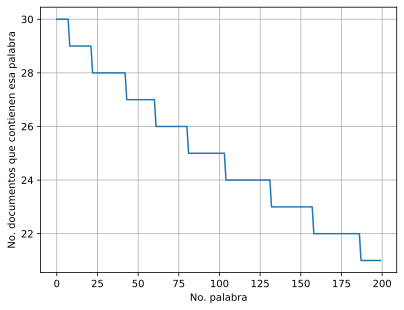

El máximo número de documentos en el que aparece una palabra es 30 y el mínimo es 21


In [40]:
n_docs_with_word = list(Vocab.dfs.values())
n_docs_with_word.sort(reverse=True)
plt.plot(n_docs_with_word)
plt.grid()
plt.xlabel('No. palabra')
plt.ylabel('No. documentos que contienen esa palabra')
plt.show()

print("El máximo número de documentos en el que aparece una palabra es {} y el mínimo es {}".format(n_docs_with_word[0], n_docs_with_word[-1]))

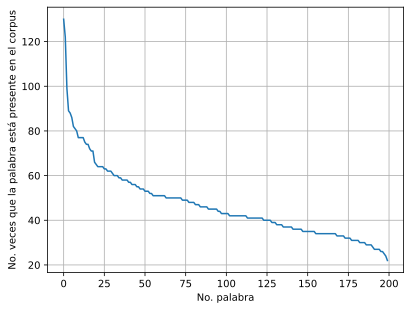

El máximo número total de veces que aparece una palabra es 130 y el mínimo es 22


In [41]:
conteo_palabras = list(Vocab.cfs.values())
conteo_palabras.sort(reverse=True)
plt.plot(conteo_palabras)
plt.grid()
plt.xlabel('No. palabra')
plt.ylabel('No. veces que la palabra está presente en el corpus')
plt.show()

print("El máximo número total de veces que aparece una palabra es {} y el mínimo es {}".format(conteo_palabras[0], conteo_palabras[-1]))

## Solution

In [ ]:
Vocab.filter_extremes(keep_n = 200)
n_tokens = len(Vocab)
print('El vocabulario tiene ahora {} palabras.'.format(n_tokens))

In [ ]:
n_docs_with_word = list(Vocab.dfs.values())
n_docs_with_word.sort(reverse=True)
plt.plot(n_docs_with_word)
plt.grid()
plt.xlabel('No. palabra')
plt.ylabel('No. documentos que contienen esa palabra')
plt.show()

print("El máximo número de documentos en el que aparece una palabra es {} y el mínimo es {}".format(n_docs_with_word[0], n_docs_with_word[-1]))

In [ ]:
conteo_palabras = list(Vocab.cfs.values())
conteo_palabras.sort(reverse=True)
plt.plot(conteo_palabras)
plt.grid()
plt.xlabel('No. palabra')
plt.ylabel('No. veces que la palabra está presente en el corpus')
plt.show()

print("El máximo número total de veces que aparece una palabra es {} y el mínimo es {}".format(conteo_palabras[0], conteo_palabras[-1]))

# 3 - Vectorización de los documentos

Una vez definido nuestro vocabulario, el último paso es **generar el BoW**. Para ello, para cada documento, tenemos que generar un **vector de longitud el vocabulario** y en cada posición un valor con el conteo o número de veces que esa palabra aparece en el documento. **Muchas de esas posiciones estarían vacías** (no todas las palabras aparecen en todos los documentos), por ello es mucho más conveniente una **representación dispersa** ("sparse"). De este modo, **cada documento se transforma en una lista de tuplas `(id, n)`**, donde `id` es el id de la palabra dentro del vocabulario y `n` el conteo de esa palabra dentro del documento.

**NOTA: Recordar la importancia de no modificar el vocabulario tras generar el BoW!**

Para generar esta lista de tuplas vamos a usar el método **`doc2bow`**. En general, **`Vocab.doc2bow(token_list)` transforma cualquier lista de tokens en una lista de tuplas `(token_id, n)`**, una por cada token en `token_list`, donde `token_id` es el identificador del token (según el vocabulario `Vocab`) y `n` es el número de ocurrencias de dicho token en `token_list`.

Veamos cómo calcular el BoW para el primer documento del corpus y analicemos la salida. **`doc2bow`  requiere como entrada una lista de tokens (tipo string) por cada documento, y procesa los documentos de uno en uno**.

In [42]:
doc = corpus_prec[9]
bow = Vocab.doc2bow(doc)

print('Documento original (tras preprocesado), primeros 10 tokens):')
print(doc[:10])
print('-' * 50)
print('\nBoW: representación en tuplas (primeros 10 elementos):')
print(bow[:10])
print('-' * 50)
print('\nEn cada tupla, el primer valor es el índice de la palabra en el documento y el segundo valor el conteo (primeros 10 elementos):')
print('-' * 50)

for tupla in bow[:10]:
  print('En la tupla {}, la palabra correspondiente al índice {} en el vocabulario es "{}" y aparece {} veces.'.format(tupla, tupla[0], Vocab[tupla[0]], tupla[1]))


print('\n Vemos también que algunas palabras están excluídas del BoW por no estar en el diccionario, como por ejemplo "compliance":')
print(Vocab.token2id.get("compliance"))


Documento original (tras preprocesado), primeros 10 tokens):
['compliance', 'usage', 'coeval', 'existence', 'federal', 'constitution', 'sanction', 'example', 'predecessor', 'career']
--------------------------------------------------

BoW: representación en tuplas (primeros 10 elementos):
[(1, 2), (3, 1), (6, 1), (7, 2), (8, 5), (13, 1), (15, 3), (17, 2), (19, 1), (20, 1)]
--------------------------------------------------

En cada tupla, el primer valor es el índice de la palabra en el documento y el segundo valor el conteo (primeros 10 elementos):
--------------------------------------------------
En la tupla (1, 2), la palabra correspondiente al índice 1 en el vocabulario es "advance" y aparece 2 veces.
En la tupla (3, 1), la palabra correspondiente al índice 3 en el vocabulario es "affair" y aparece 1 veces.
En la tupla (6, 1), la palabra correspondiente al índice 6 en el vocabulario es "benefit" y aparece 1 veces.
En la tupla (7, 2), la palabra correspondiente al índice 7 en el vo

**NOTA IMPORTANTE:** Observar cómo el orden de las palabras en el documento no se corresponde con el orden de las palabras en el BoW, éste sigue el orden marcado por el vocabulario.

In [44]:
for k in range(10):
  print("En el vocabulario, la palabra correspondiente al índice {} es {}.".format(k, D[k]))


NameError: name 'D' is not defined

## Ejercicio

Obtenga el BoW de todos los documentos del corpus usando una "list comprehension".

Almacene la salida en una lista llamada `corpus_bow` donde cada elemento de la lista sea el BoW de un documento, para a continuación poder analizar la salida y representarla.

Presente detalles para el documento número 50 y los 10 primeros elementos del BOW. Represente el número de apariciones de cada palabra usando un diagrama de barras.

In [ ]:
# List comprehension para procesar todos los documentos del corpus
corpus_bow = <INSERT CODE HERE>

In [ ]:
n_doc=50
print('Documento original (tras preprocesado), primeros 20 tokens):')
print(corpus_prec[n_doc][:10])
print('-' * 50)

print('\nRepresentación vectorial dispersa (10 elementos con más apariciones):')
sorted_bow_n_doc = <INSERT CODE HERE>
print(sorted_bow_n_doc[:10])
print('-' * 50)

print('\nEsta es la lista de tuplas, donde en cada una el primer valor es el índice de la palabra en el documento y el segundo valor el conteo (primeros 10 elementos):')
list_word_counts = <INSERT CODE HERE>
print(list_word_counts)

In [ ]:
words = <INSERT CODE HERE>
counts = <INSERT CODE HERE>

plt.figure(figsize=(8,5))
plt.bar(words,counts)
plt.xlabel('Words')
plt.ylabel('Counts')
plt.xticks(rotation=90)
plt.grid()
plt.show()

## Solution

In [45]:
# List comprehension para procesar todos los documentos del corpus
corpus_bow = [Vocab.doc2bow(doc) for doc in corpus_prec]

In [46]:
n_doc=50
print('Documento original (tras preprocesado), primeros 20 tokens):')
print(corpus_prec[n_doc][:10])
print('-' * 50)

print('\nRepresentación vectorial dispersa (10 elementos con más apariciones):')
sorted_bow_n_doc = sorted(corpus_bow[n_doc], key=lambda x: -x[1])
print(sorted_bow_n_doc[:10])
print('-' * 50)

print('\nEsta es la lista de tuplas, donde en cada una el primer valor es el índice de la palabra en el documento y el segundo valor el conteo (primeros 10 elementos):')
list_word_counts = [(Vocab[doc_bow[0]], doc_bow[1]) for doc_bow in sorted_bow_n_doc[:10]]
print(list_word_counts)

Documento original (tras preprocesado), primeros 20 tokens):
['chief', 'justice', 'president', 'vice', 'president', 'quayle', 'senator', 'mitchell', 'speaker', 'wright']
--------------------------------------------------

Representación vectorial dispersa (10 elementos con más apariciones):
[(92, 9), (165, 7), (198, 7), (89, 5), (98, 5), (152, 5), (181, 5), (197, 5), (119, 4), (128, 4)]
--------------------------------------------------

Esta es la lista de tuplas, donde en cada una el primer valor es el índice de la palabra en el documento y el segundo valor el conteo (primeros 10 elementos):
[('friend', 9), ('word', 7), ('today', 7), ('fact', 5), ('like', 5), ('child', 5), ('turn', 5), ('help', 5), ('ask', 4), ('generation', 4)]


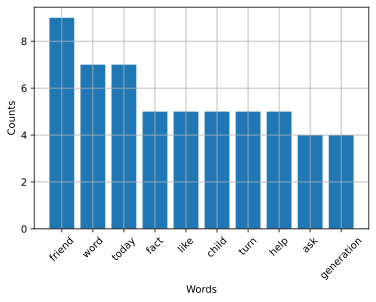

In [47]:
words = [e[0] for e in list_word_counts]
counts = [e[1] for e in list_word_counts]

plt.figure(figsize=(6,4))
plt.bar(words,counts)
plt.xlabel('Words')
plt.ylabel('Counts')
plt.xticks(rotation=45)
plt.grid()
plt.show()

# 4 - Representación TF-IDF

Un problema del BoW es que **la frecuencia de las palabras muy frecuentes empiezan a dominar en el documento respecto al resto**; por ejemplo, verbos muy comunes o términos habituales en el contexto del corpus pero no tienen tanto "contenido informativo" para el modelo como pueden ser palabras más raras pero tal vez específicas del dominio.

Al realizar la gestión del vocabulario hemos visto que podemos eliminar estas palabras tan frecuentes, pero este proceso es bastante manual y **es preferible tener una vectorización robusta a este efecto**.






Para ello, la representación **TF-IDF (Term Frequency–Inverse Document Frequency) propone reajustar la frecuencia de las palabras en función de la frecuencia con que aparecen en todos los documentos**, de modo que se penalicen las puntuaciones de palabras frecuentes si también son frecuentes en todos los documentos. Para ello, el TF-IDF implica el cálculo de dos valores:


**Frecuencia de término (TF)**

Por frecuencia de término $\text{TF}(w)$ nos referimos al número de veces que una palabra $w$ dada ocurre en un documento, dividido por el número total de palabras en dicho documento.
$$ \text{TF}(w,d) =\frac{\text{# veces que $w$ aparece en el documento $d$}}{\text{# total de palabras en el documento $d$}}$$

**Frecuencia de Documento Inversa (IDF)**

Es una medida de cuánta información proporciona la palabra $w$, es decir, si es común o rara en todos los documentos del corpus $D$. Se calcula de la siguiente manera:
$$ \text{IDF}(w,D) =\log \frac{\text{# documentos en el corpus}}{1+\text{# documentos donde la palabra $w$ aparece}}$$

A partir de estos valores el **TF-IDF** se calcula de la siguiente manera:

$$\text{TF-IDF}(w,d,D) = \text{TF}(w,d) * \text{IDF}(w,D)$$

Un **peso alto** en TF-IDF se consigue cuando la **palabra tiene una frecuencia alta en el documento y, a la vez, una frecuencia baja en el corpus**; por lo tanto, los pesos tienden a filtrar los términos que son comunes a muchos documentos.


Obsérvese que, a diferencia de la vectorización BoW, para el **TF-IDF tenemos que obtener la vectorización conjuntamente con todo el corpus**, no documento a documento.

No obstante, una vez que hemos calculado el BoW para todos los documentos, aprender el modelo TF-IDF es sencillo usando la función [**TfidfModel**](https://radimrehurek.com/gensim/models/tfidfmodel.html) de **Gensim**.

**Nota: Prestemos atención al tipo de formato del corpus necesario para entrenar el modelo TF-IDF: requiere una entrada tipo BOW:**

In [48]:
print('Esta es la estructura del BOW de entrada: lista de listas de tuplas de longitud {}'.format(len(corpus_bow)))
print(type(corpus_bow))
print(type(corpus_bow[0]))
print(type(corpus_bow[0][0]))

print("\nEl BOW es una lista de listas de tuplas.")

print("\nEjemplo de una fila del BOW:")
print(corpus_bow[0])

Esta es la estructura del BOW de entrada: lista de listas de tuplas de longitud 60
<class 'list'>
<class 'list'>
<class 'tuple'>

El BOW es una lista de listas de tuplas.

Ejemplo de una fila del BOW:
[(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 2), (9, 2), (10, 1), (11, 2), (12, 1), (13, 1), (14, 1), (15, 1), (16, 1), (17, 1), (18, 1), (19, 1), (20, 1), (21, 1), (22, 3), (23, 2), (24, 1), (25, 1), (26, 1), (27, 1), (28, 1), (29, 1), (30, 1), (31, 3), (32, 2), (33, 1), (34, 1), (35, 2), (36, 1), (37, 1), (38, 1), (39, 1), (40, 3), (41, 2), (42, 2), (43, 1), (44, 2), (45, 4), (46, 1), (47, 1), (48, 1), (49, 2), (50, 1), (51, 1), (52, 1), (53, 1), (54, 1), (55, 1), (56, 1), (57, 1), (58, 2), (59, 1), (60, 1), (61, 1), (62, 1), (63, 2), (64, 1), (65, 2), (66, 2)]


In [49]:
from gensim.models import TfidfModel

# Ajustamos el modelo TFIDF usando TODO EL CORPUS
model = TfidfModel(corpus_bow)

# apply model to the first corpus document
vector = model[corpus_bow[0]]  # apply model to the first corpus document
print(vector[:20])



[(0, np.float64(0.0850222113519678)), (1, np.float64(0.07071863801611668)), (2, np.float64(0.09309595850131044)), (3, np.float64(0.07759508394330833)), (4, np.float64(0.06746252998639686)), (5, np.float64(0.08123435655307555)), (6, np.float64(0.08897129913196959)), (7, np.float64(0.07071863801611668)), (8, np.float64(0.15519016788661666)), (9, np.float64(0.14143727603223336)), (10, np.float64(0.07759508394330833)), (11, np.float64(0.1481863512362243)), (12, np.float64(0.07759508394330833)), (13, np.float64(0.08897129913196959)), (14, np.float64(0.09309595850131044)), (15, np.float64(0.08123435655307555)), (16, np.float64(0.08897129913196959)), (17, np.float64(0.09741253015681196)), (18, np.float64(0.07409317561811216)), (19, np.float64(0.07071863801611668))]


A continuación obtenemos el TFIDF de todos los documentos del corpus. Al igual que el ajuste del modelo, la vectorización TFIDF se calcula sobre todo el corpus BoW.

La salida será `corpus_tfifd`, de tipo **`TransformedCorpus`** pero indexado como una lista y donde cada elemento es el TFIDF de un documento, para poder analizar la salida y representarla de igual modo que en el caso del BOW.

In [51]:
# Apply TFIDF model to all corpus document
corpus_tfidf = model[corpus_bow]

print('Esta es la estructura del BOW de entrada: lista de listas de tuplas de longitud {}'.format(len(corpus_bow)))
print(type(corpus_bow))
print(type(corpus_bow[0]))
print(type(corpus_bow[0][0]))
print(corpus_bow[0][0:10])

print('\nEsta es la estructura del TFIDF de salida: objeto TransformedCorpus, de longitud {}'.format(len(corpus_tfidf)))
print(type(corpus_tfidf))

print("\nEs una estructura de datos indexada, cada elemento es una lista de tuplas, análogo al BOW pero con ponderaciones en vez de conteos:")
print(type(corpus_tfidf[0]))
print(type(corpus_tfidf[0][0]))
print(corpus_tfidf[0][0:10])



Esta es la estructura del BOW de entrada: lista de listas de tuplas de longitud 60
<class 'list'>
<class 'list'>
<class 'tuple'>
[(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 2), (9, 2)]

Esta es la estructura del TFIDF de salida: objeto TransformedCorpus, de longitud 60
<class 'gensim.interfaces.TransformedCorpus'>

Es una estructura de datos indexada, cada elemento es una lista de tuplas, análogo al BOW pero con ponderaciones en vez de conteos:
<class 'list'>
<class 'tuple'>
[(0, np.float64(0.0850222113519678)), (1, np.float64(0.07071863801611668)), (2, np.float64(0.09309595850131044)), (3, np.float64(0.07759508394330833)), (4, np.float64(0.06746252998639686)), (5, np.float64(0.08123435655307555)), (6, np.float64(0.08897129913196959)), (7, np.float64(0.07071863801611668)), (8, np.float64(0.15519016788661666)), (9, np.float64(0.14143727603223336))]


Analicemos esta transformación en comparación con el BoW

In [52]:
n_doc=50
print('Documento original tras preprocesado, primeros 20 tokens):')
print(corpus_prec[n_doc][:10])
print('-' * 50)

Documento original tras preprocesado, primeros 20 tokens):
['chief', 'justice', 'president', 'vice', 'president', 'quayle', 'senator', 'mitchell', 'speaker', 'wright']
--------------------------------------------------


In [53]:
print('\nRepresentación vectorial dispersa (10 elementos con más apariciones):')
sorted_tfidf_n_doc = sorted(corpus_tfidf[n_doc], key=lambda x: -x[1])
print(sorted_tfidf_n_doc[:10])
print('-' * 50)


Representación vectorial dispersa (10 elementos con más apariciones):
[(92, np.float64(0.42678309227102057)), (165, np.float64(0.2894989624670813)), (198, np.float64(0.23995917933666364)), (89, np.float64(0.22657770056517906)), (197, np.float64(0.22657770056517906)), (181, np.float64(0.2164833567841769)), (152, np.float64(0.20678497319077238)), (151, np.float64(0.17318668542734153)), (171, np.float64(0.17318668542734153)), (98, np.float64(0.1713994138119026))]
--------------------------------------------------


In [54]:
print('\nEsta es la lista de tuplas, donde en cada una el primer valor es el índice de la palabra en el documento y el segundo valor el conteo (primeros 10 elementos):')
list_word_counts_bow = [(Vocab[doc_bow[0]], doc_bow[1]) for doc_bow in sorted_bow_n_doc[:10]]
for tupla in list_word_counts_bow:
  print(tupla)
print('-' * 50)


Esta es la lista de tuplas, donde en cada una el primer valor es el índice de la palabra en el documento y el segundo valor el conteo (primeros 10 elementos):
('friend', 9)
('word', 7)
('today', 7)
('fact', 5)
('like', 5)
('child', 5)
('turn', 5)
('help', 5)
('ask', 4)
('generation', 4)
--------------------------------------------------


In [55]:
print('\nEsta es la lista de tuplas, donde en cada una el primer valor es el índice de la palabra en el documento y el segundo valor el conteo (primeros 10 elementos):')
list_word_counts_tfidf = [(Vocab[doc_bow[0]], doc_bow[1]) for doc_bow in sorted_tfidf_n_doc[:10]]
for tupla in list_word_counts_tfidf:
  print(tupla)
print('-' * 50)


Esta es la lista de tuplas, donde en cada una el primer valor es el índice de la palabra en el documento y el segundo valor el conteo (primeros 10 elementos):
('friend', np.float64(0.42678309227102057))
('word', np.float64(0.2894989624670813))
('today', np.float64(0.23995917933666364))
('fact', np.float64(0.22657770056517906))
('help', np.float64(0.22657770056517906))
('turn', np.float64(0.2164833567841769))
('child', np.float64(0.20678497319077238))
('begin', np.float64(0.17318668542734153))
('remember', np.float64(0.17318668542734153))
('like', np.float64(0.1713994138119026))
--------------------------------------------------


Observamos que la importancia de las palabras ha variado entre el BOW y el TFIDF.

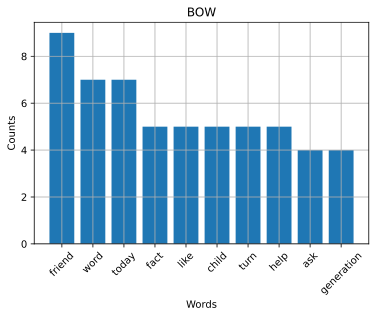

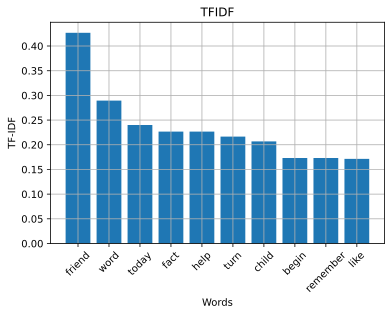

In [56]:
# Plot again (BOW)
words = [e[0] for e in list_word_counts_bow]
counts = [e[1] for e in list_word_counts_bow]

plt.figure(figsize=(6,4))
plt.bar(words,counts)
plt.xlabel('Words')
plt.ylabel('Counts')
plt.xticks(rotation=45)
plt.grid()
plt.title('BOW')
plt.show()

# Plot again (TFIDF)
words = [e[0] for e in list_word_counts_tfidf]
counts = [e[1] for e in list_word_counts_tfidf]

plt.figure(figsize=(6,4))
plt.bar(words,counts)
plt.xlabel('Words')
plt.ylabel('TF-IDF')
plt.xticks(rotation=45)
plt.grid()
plt.title('TFIDF')
plt.show()

Compare ambas representaciones... ¿Qué palabras tenían más/menos peso en la representación BoW? ¿Hay palabras con el mismo peso? ¿Y en la representación TF-IDF?

# 5 - Limitaciones de BoW y TF-IDF

Las **representaciones vectoriales** que acabamos de ver son sencillas de comprender y aplicar y ofrecen mucha **flexibilidad** para manejo de información textual. De hecho, se han utilizado con gran éxito en problemas de **predicción y clasificación de documentos**.

Sin embargo, sufre de algunas **deficiencias** que tenemos que tener en cuenta:

* **Vocabulario**: **requiere un diseño cuidadoso**, más específicamente para gestionar su tamaño, lo que afecta a la dispersión de las representaciones de los documentos.

* Dispersión: Las **representaciones dispersas son más difíciles de modelar** tanto por razones computacionales como por razones de información, en las que el reto es que los modelos aprovechen la poca información común en un espacio de representación tan grande.

* **Significado**: Al **descartar el orden de las palabras se ignora el contexto** y, a su vez, el significado de las palabras del documento (**semántica**). El contexto y el significado pueden ofrecer mucho al modelo, que si se modela podría diferenciar entre las mismas palabras dispuestas de manera diferente ("esto es interesante" vs "es esto interesante?"), sinónimos ("bicicleta vieja" vs "bicicleta usada"), y mucho más.

# 6 - Uso de la representación vectorial en modelos de aprendizaje

Una vez tenemos una **representación vectorial** para cada documento del corpus podemos usar los modelos de aprendizaje que conocemos para resolver diferentes tareas. Por ejemplo, si este corpus estuviese distribuido por categorías, podríamos aprender un modelo para clasificar automáticamente los textos en las diferentes categorías. Como el corpus con el que estamos trabajando no está etiquetado, vamos a usar la representación vectorial que hemos obtenido para hacer un **agrupamiento de los documentos usando un K-means** y luego analizar qué información nos da este agrupamiento.

## 6.1 - Codificación dispersa de los datos

**No todos las librerías de aprendizaje automático están diseñadas para trabajar con datos dispersos** (conviene revisar la documentación de cada librería al respecto). A modo de ejemplo, vamos a usar aquí las librerías de **Sklearn**, tras convertir nuestra representación vectorial dispersa en **numpy arrays** "densos". Para ello, **Gensim** nos incluye dos funciones: [**corpus2dense**](https://tedboy.github.io/nlps/generated/generated/gensim.matutils.corpus2dense.html), [**corpus2csc**](https://tedboy.github.io/nlps/generated/generated/gensim.matutils.corpus2csc.html)

In [57]:
from gensim.matutils import corpus2dense, corpus2csc

n_tokens = len(Vocab)
num_docs = len(corpus_bow)

# Convert BoW representacion
print("Esta es la representación del BOW en formato denso:")
corpus_bow_dense = corpus2dense(corpus_bow, num_terms=n_tokens, num_docs=num_docs).T
print(type(corpus_bow_dense))
print(corpus_bow_dense.shape)

print("\nEsta es la representación del BOW en formato denso:")
corpus_bow_sparse = corpus2csc(corpus_bow, num_terms=n_tokens, num_docs=num_docs).T
print(type(corpus_bow_sparse))
print(corpus_bow_sparse.shape)

# Convert TFIDF representacion
print("\nEsta es la representación del TFIDF en formato denso:")
corpus_tfidf_dense = corpus2dense(corpus_tfidf, num_terms=n_tokens, num_docs=num_docs).T
print(type(corpus_tfidf_dense))
print(corpus_tfidf_dense.shape)

print("\nEsta es la representación del TFIDF en formato denso:")
corpus_tfidf_sparse = corpus2csc(corpus_tfidf, num_terms=n_tokens, num_docs=num_docs).T
print(type(corpus_tfidf_sparse))
print(corpus_tfidf_sparse.shape)

Esta es la representación del BOW en formato denso:
<class 'numpy.ndarray'>
(60, 200)

Esta es la representación del BOW en formato denso:
<class 'scipy.sparse._csr.csr_matrix'>
(60, 200)

Esta es la representación del TFIDF en formato denso:
<class 'numpy.ndarray'>
(60, 200)

Esta es la representación del TFIDF en formato denso:
<class 'scipy.sparse._csr.csr_matrix'>
(60, 200)


**IMPORTANTE: note que hace falta conocer el número de documentos y el número de elementos en el vocabulario** para utilizar "corpus2dense" y "corpus2csc".

Una vez convertidos a **Numpy array denso** o **matrix dispersa CSC de Scipy**, ambas parametrizaciones tienen en mismo formato y se pueden tratar de la misma forma. **Incluso las librerías que pueden trabajar con datos en formato disperso, suelen requerir formato CSC de scipy, no trabajan directamente con el formato de lista de tuplas generado por Gensim**.

Veamos qué han hecho estas transformaciones, por ejemplo, para la representación BoW (nótese que los elementos del BOW se presentan ordenados, según el orden de las palabras del vocabulario):

In [58]:
print(corpus_bow[50][:10])


[(1, 1), (7, 1), (9, 2), (10, 2), (11, 1), (16, 1), (23, 2), (24, 1), (26, 1), (27, 1)]


En el caso del TFIDF denso, aparecen rellenas con ceros las posiciones vacías.

In [59]:
print(corpus_bow_dense[50,:20])

[0. 1. 0. 0. 0. 0. 0. 1. 0. 2. 2. 1. 0. 0. 0. 0. 1. 0. 0. 0.]


Si localizamos las posiciones no nulas en el array, vemos que coinciden con los índices del BOW:

In [60]:
np.nonzero(corpus_bow_dense[50,:20])

(array([ 1,  7,  9, 10, 11, 16]),)

El formato disperso CSC de Scipy tiene estructura propia, según sea una fila del BOW o una parte del mismo. **Hay que tener cuidado si se manejan trozos de matrices, las coordenadas se refieren al trozo elegido, no al total**:

In [61]:
print('El BOW de un documento (10 primeros elementos):')
print(corpus_bow_sparse[50,1:20])

print('\nUn trozo del BOW completo (10 primeros elementos):')
print(corpus_bow_sparse[1:5,1:5])

El BOW de un documento (10 primeros elementos):
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 6 stored elements and shape (1, 19)>
  Coords	Values
  (0, 0)	1.0
  (0, 6)	1.0
  (0, 8)	2.0
  (0, 9)	2.0
  (0, 10)	1.0
  (0, 15)	1.0

Un trozo del BOW completo (10 primeros elementos):
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 6 stored elements and shape (4, 4)>
  Coords	Values
  (1, 1)	1.0
  (2, 0)	3.0
  (2, 2)	1.0
  (3, 0)	2.0
  (3, 2)	3.0
  (3, 3)	1.0


En general, cuando tengamos **grandes corpus**, nos interesará manejar la **representación dispersa o sparse** de los datos para ahorrar en coste computacional. Si en nuestro procesado de ML usamos Sklearn podremos trabajar con este formato sparse ya que la mayoría de clasificadores/regresores puede trabajar con ambos datos densos y dispersos.

Pasemos ahora a aplicar un agrupamiento o clustering de nuestros documentos usando ambas representaciones vectoriales (BoW y TFIDF). En ambos casos usaremos la representación sparse de los datos.

## 6.2 - Calculo de distancias entre representaciones BoW y TF-IDF

Una vez que tenemos la representación vectorial de nuestros documentos (cada una de las filas de la matriz BoW o tfidf), muchos de nuestros modelos de ML necesitarán **calcular similitudes entre ellos**, como puede ser un algoritmo **K-NN para regresión** o un **K-means para agrupamiento**. Para ello, cuando trabajamos  con características BoW o TFIDF, donde la magnitud de los vectores no es tan decisiva, suele utilizarse como métrica la **similitud del coseno**.

Podríamos suponer que cuando una palabra (por ejemplo, ciencia) aparece con más frecuencia en el documento 1 que en el 2, ese documento 1 está más relacionado con el tema de la ciencia. Sin embargo, también podría darse el caso de que estemos trabajando con documentos de longitudes desiguales (artículos de Wikipedia, por ejemplo). En ese caso, es probable que la ciencia aparezca más en el documento 1 sólo porque es mucho más largo que el documento 2. **La similitud del coseno corrige estos sesgos**.












Por esta razón, cuando se trabaja con documentos codificados con BoW o TF-IDF, se tiende a utilizar la similitud del coseno (**coseno del ángulo que forman ambos vectores**). Si $\mathbf{v}_1$ y $\mathbf{v}_2$ son dos vectores TF-IDF, la similitud del coseno se calcula como sigue:

$$\text{cos}(\mathbf{v}_1,\mathbf{v}_2) = \frac{\mathbf{v}_1^T~\mathbf{v}_2}{||\mathbf{v}_1||_2 ||\mathbf{v}_2||}$$

O, más bien se usa la distancia coseno definida como $1-\text{cos}(\mathbf{v}_1,\mathbf{v}_2) $, es decir,
$$d_\text{cos}(\mathbf{v}_1,\mathbf{v}_2) = 1- \frac{\mathbf{v}_1^T~\mathbf{v}_2}{||\mathbf{v}_1||_2 ||\mathbf{v}_2||}$$



<img src="http://www.tsc.uc3m.es/~navia/figures/NLP1.png" width="100%">





Y como podemos ver en la siguiente figura, sus resultados **no tienen nada que ver con la distancia euclídea (no dependen de la longitud de los vectores)**.

<img src="http://www.tsc.uc3m.es/~navia/figures/NLP2.png" width="60%">

Otro aspecto que tenemos que tener en cuenta es que **la distancia coseno no es formalmente una "distancia" como tal** (no cumple la desigualdad triangular) e **implementaciones por defecto** de nuestros modelos de aprendizaje como el K-NN o K-means de sklearn usan la **distancia euclídea por defecto** y no permiten incluir la distancia coseno.

Para solventar este problema tenemos dos opciones:

* **Usar otras implementaciones** como K-means de NLTK que nos permite usar la distancia coseno. Aunque el problema de esta implementación es que **no nos deja trabajar con matrices sparse**.

* **Reescalar nuestros datos para poder utilizar implementaciones basadas en la distancia euclídea**... (luego explicaremos en qué consiste esta aproximación).

# 7 - Agrupamiento de documentos usando K-means sobre vectorizaciones BoW y TFIDF

Empecemos haciendo agrupamiento de datos usando la librería de NLTK que nos permite usar la distancia coseno.

Aunque, tal y como hemos comentado, el problema de esta implementación es que no nos deja trabajar con matrices sparse; así que tenemos que usar el método `.toarray()` para convertir nuestros vectores sparse en numpy arrays (o usar la conversión a matrices densas de gensim).

In [62]:
# Transform data to dense
corpus_bow_array = corpus_bow_sparse.toarray()
corpus_tfidf_array = corpus_tfidf_sparse.toarray()

Ahora entrenaremos el K-means con 4 centroides, tanto para la representación BoW como TF-IDF y analizaremos los resultados.

## 7.1 - Clustering de documentos con BoW

In [95]:
from nltk.cluster.kmeans import KMeansClusterer

K=4
kclusterer = KMeansClusterer(K, distance=nltk.cluster.util.cosine_distance, repeats=1000)

y_kmeans = kclusterer.cluster(corpus_bow_array, assign_clusters=True)
centers = kclusterer.means()

In [98]:
print(y_kmeans)
print(len(y_kmeans))

[2, 3, 3, 2, 2, 2, 2, 2, 2, 2, 3, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 3, 3, 0, 3, 0, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0]
60


In [ ]:
print(centers[0])
print(len(centers[0]))


[0.26666667 0.86666667 0.06666667 0.46666667 0.6        0.33333333
 0.6        0.26666667 0.26666667 0.53333333 0.66666667 0.73333333
 0.2        0.06666667 0.33333333 0.33333333 0.2        0.26666667
 0.53333333 1.06666667 0.2        0.66666667 0.53333333 0.33333333
 0.2        0.2        0.33333333 0.13333333 0.13333333 0.06666667
 0.53333333 0.26666667 0.2        0.53333333 0.         0.66666667
 0.33333333 0.53333333 0.13333333 0.8        0.33333333 0.33333333
 0.26666667 0.2        1.06666667 0.13333333 0.13333333 0.46666667
 0.4        0.46666667 0.46666667 0.2        0.73333333 0.33333333
 0.2        0.46666667 0.2        0.4        0.6        0.46666667
 0.13333333 0.06666667 1.66666667 0.6        1.2        1.2
 0.06666667 0.46666667 0.2        0.33333333 0.93333333 0.46666667
 0.2        0.66666667 0.4        0.33333333 0.73333333 0.46666667
 0.66666667 0.66666667 0.33333333 0.46666667 0.2        0.33333333
 0.         0.2        0.8        0.26666667 0.33333333 0.73333333
 0

¿Qué documentos están en cada grupo? ¿Qué información (textual) hay en cada grupo?

In [84]:
# Palabras más relevantes por centroide
n_center = 0
fileids = inaugural.fileids()
y_kmeans = np.array(y_kmeans)
for i, center_i in enumerate(centers):
    print('Centroide %d' %(i))
    # Find documents in this centroid
    pos_y = np.where(y_kmeans==i)[0]
    print('Elementos grupo %d' %(i))
    id_grupo = [fileids[pos] for pos in pos_y]
    print(id_grupo)

    # Find the ten most relevant words for this centroid
    pos_sort = np.argsort(centers[i])[::-1][:10]
    words_center = [Vocab[p] for p in pos_sort]
    print(words_center)
    print('********')


Centroide 0
Elementos grupo 0
['1941-Roosevelt.txt', '1945-Roosevelt.txt', '1965-Johnson.txt', '1969-Nixon.txt', '1993-Clinton.txt', '1997-Clinton.txt', '2001-Bush.txt', '2009-Obama.txt', '2013-Obama.txt', '2017-Trump.txt', '2021-Biden.txt', '2025-Trump.txt']
['today', 'americans', 'child', 'century', 'promise', 'generation', 'like', 'build', 'moment', 'earth']
********
Centroide 1
Elementos grupo 1
['1905-Roosevelt.txt', '1913-Wilson.txt', '1933-Roosevelt.txt', '1937-Roosevelt.txt', '1949-Truman.txt', '1953-Eisenhower.txt', '1957-Eisenhower.txt', '1961-Kennedy.txt', '1973-Nixon.txt', '1977-Carter.txt', '1981-Reagan.txt', '1985-Reagan.txt', '1989-Bush.txt', '2005-Bush.txt']
['help', 'today', 'americans', 'ask', 'earth', 'face', 'problem', 'friend', 'century', 'use']
********
Centroide 2
Elementos grupo 2
['1789-Washington.txt', '1793-Washington.txt', '1801-Jefferson.txt', '1805-Jefferson.txt', '1809-Madison.txt', '1817-Monroe.txt', '1825-Adams.txt', '1833-Jackson.txt', '1837-VanBuren.t

## 7.2 - Clustering de documentos con TF-IDF

In [66]:
K=4
kclusterer = KMeansClusterer(4, distance=nltk.cluster.util.cosine_distance, repeats=10)

y_kmeans = kclusterer.cluster(corpus_tfidf_array, assign_clusters=True)
centers = kclusterer.means()

In [67]:
# Palabras más relevantes por centroide
n_center = 0
fileids = inaugural.fileids()
y_kmeans = np.array(y_kmeans)
for i, center_i in enumerate(centers):
  print('Centroide %d' %(i))
  # Find documents in this centroid
  pos_y = np.where(y_kmeans==i)[0]
  print('Elementos grupo %d' %(i))
  id_grupo = [fileids[pos] for pos in pos_y]
  print(id_grupo)

  # Find the ten most relevant words for this centroid
  pos_sort = np.argsort(centers[i])[::-1][:10]
  words_center = [Vocab[p] for p in pos_sort]
  print(words_center)
  print('********')


Centroide 0
Elementos grupo 0
['1913-Wilson.txt', '1941-Roosevelt.txt', '1945-Roosevelt.txt', '1953-Eisenhower.txt', '1957-Eisenhower.txt', '1961-Kennedy.txt', '1965-Johnson.txt', '1969-Nixon.txt', '1973-Nixon.txt', '1977-Carter.txt', '1981-Reagan.txt', '1985-Reagan.txt', '1989-Bush.txt', '1993-Clinton.txt', '1997-Clinton.txt', '2001-Bush.txt', '2005-Bush.txt', '2009-Obama.txt', '2013-Obama.txt', '2017-Trump.txt', '2021-Biden.txt', '2025-Trump.txt']
['americans', 'today', 'help', 'child', 'build', 'century', 'generation', 'friend', 'word', 'promise']
********
Centroide 1
Elementos grupo 1
['1905-Roosevelt.txt', '1917-Wilson.txt', '1933-Roosevelt.txt', '1937-Roosevelt.txt']
['problem', 'wish', 'face', 'task', 'help', 'self', 'mankind', 'moral', 'essential', 'use']
********
Centroide 2
Elementos grupo 2
['1793-Washington.txt', '1797-Adams.txt', '1813-Madison.txt', '1817-Monroe.txt', '1821-Monroe.txt', '1825-Adams.txt', '1829-Jackson.txt', '1841-Harrison.txt', '1849-Taylor.txt', '1865-Lin

Analice y discuta los resultados de ambos clusters para cada tipo de vectorización.

## 7.3 - Entrenando el K-means de sklearn

Como hemos dicho anteriormente, no podemos usar las librerías de K-means o K-NN de sklearn con representaciones BOW o TF-IDF porque **solo permiten usar la distancia euclídea**.

Sin embargo, cuando nuestros **vectores $x$ e $y$ están normalizados** ($||x||^2 = x^Tx = 1$), sus distancias euclídeas $||x-y||^2$  y coseno $d(x,y)$ están relacionas por la siguiente igualdad:

$$||x-y||^2 = x^Tx + y^Ty - 2 x^Ty = 2  (1 - x^Ty) = 2  d(x,y)$$

 En este caso, usar la distancia euclídea nos va a dar los mismos resultados que la distancia coseno.

Nótese que esta normalización es parecida al cálculo TF que compensa en la representación BoW la longitud de los documentos.

Así que comencemos normalizando nuestros datos para que cada vector tenga norma unidad (vamos a hacerlo sobre las reprentaciones sparse).


In [99]:
from scipy import sparse

def normalize_sparse_vector(s):
    norm_s = np.array(np.sqrt(s.multiply(s).sum(1)))
    pos_zero = np.where(np.sqrt(s.multiply(s).sum(1))==0)[0]
    norm_s[pos_zero] = 1
    return s.multiply(sparse.csr_matrix(1/norm_s))

corpus_bow_sparse_norm = normalize_sparse_vector(corpus_bow_sparse)
corpus_tfidf_sparse_norm = normalize_sparse_vector(corpus_tfidf_sparse)

Ahora claculemos el clustering con el K-means de sklearn

## 7.4 Resultados con Sklearn y BoW

In [100]:
from sklearn.cluster import KMeans

# K-means with K=4 (we could use the silhouette score to adjust this parameter) and 10 initializations
K=4
kmeans = KMeans(n_clusters=K, n_init=10) # Definimos objeto con parámetros por defecto

kmeans.fit(corpus_bow_sparse_norm) # Entrenamos k-means usando el BoW
y_kmeans = kmeans.predict(corpus_bow_sparse_norm) # Obtenemos el identificador del grupo para cada dato
centers = kmeans.cluster_centers_ # Obtenemos los centroides

In [101]:
# Palabras más relevantes por centroide
n_center = 0
fileids = inaugural.fileids()
y_kmeans = np.array(y_kmeans)
for i, center_i in enumerate(centers):
  print('Centroide %d' %(i))
  # Find documents in this centroid
  pos_y = np.where(y_kmeans==i)[0]
  print('Elementos grupo %d' %(i))
  id_grupo = [fileids[pos] for pos in pos_y]
  print(id_grupo)

  # Find the ten most relevant words for this centroid
  pos_sort = np.argsort(centers[i])[::-1][:10]
  words_center = [Vocab[p] for p in pos_sort]
  print(words_center)
  print('********')

Centroide 0
Elementos grupo 0
['1789-Washington.txt', '1793-Washington.txt', '1797-Adams.txt', '1809-Madison.txt', '1813-Madison.txt', '1817-Monroe.txt', '1821-Monroe.txt', '1829-Jackson.txt', '1841-Harrison.txt', '1849-Taylor.txt', '1857-Buchanan.txt', '1865-Lincoln.txt', '1869-Grant.txt', '1873-Grant.txt', '1885-Cleveland.txt', '1889-Harrison.txt', '1893-Cleveland.txt', '1897-McKinley.txt', '1901-McKinley.txt', '1909-Taft.txt']
['congress', 'executive', 'necessary', 'proper', 'commerce', 'object', 'aid', 'condition', 'occasion', 'institution']
********
Centroide 1
Elementos grupo 1
['1941-Roosevelt.txt', '1945-Roosevelt.txt', '1957-Eisenhower.txt', '1961-Kennedy.txt', '1965-Johnson.txt', '1969-Nixon.txt', '1973-Nixon.txt', '1977-Carter.txt', '1981-Reagan.txt', '1985-Reagan.txt', '1989-Bush.txt', '1993-Clinton.txt', '1997-Clinton.txt', '2001-Bush.txt', '2005-Bush.txt', '2009-Obama.txt', '2013-Obama.txt', '2017-Trump.txt', '2021-Biden.txt', '2025-Trump.txt']
['today', 'americans', 'chi

## 7.5 - Resultados con Sklearn y TF-IDF

In [102]:
# K-means with K=4 (we could use the silhouette score to adjust this parameter) and 10 initializations
K=4
kmeans = KMeans(n_clusters=K, n_init=10) # Definimos objeto con parámetros por defecto

kmeans.fit(corpus_tfidf_sparse_norm) # Entrenamos k-means usando el BoW
y_kmeans = kmeans.predict(corpus_tfidf_sparse_norm) # Obtenemos el identificador del grupo para cada dato
centers = kmeans.cluster_centers_ # Obtenemos los centroides

In [103]:
# Palabras más relevantes por centroide
n_center = 0
fileids = inaugural.fileids()
y_kmeans = np.array(y_kmeans)
for i, center_i in enumerate(centers):
  print('Centroide %d' %(i))
  # Find documents in this centroid
  pos_y = np.where(y_kmeans==i)[0]
  print('Elementos grupo %d' %(i))
  id_grupo = [fileids[pos] for pos in pos_y]
  print(id_grupo)

  # Find the ten most relevant words for this centroid
  pos_sort = np.argsort(centers[i])[::-1][:10]
  words_center = [Vocab[p] for p in pos_sort]
  print(words_center)
  print('********')

Centroide 0
Elementos grupo 0
['1905-Roosevelt.txt', '1913-Wilson.txt', '1917-Wilson.txt', '1921-Harding.txt', '1933-Roosevelt.txt', '1941-Roosevelt.txt', '1949-Truman.txt', '1953-Eisenhower.txt', '1957-Eisenhower.txt']
['help', 'task', 'face', 'problem', 'mankind', 'wish', 'body', 'prove', 'use', 'knowledge']
********
Centroide 1
Elementos grupo 1
['1937-Roosevelt.txt', '1945-Roosevelt.txt', '1961-Kennedy.txt', '1965-Johnson.txt', '1969-Nixon.txt', '1973-Nixon.txt', '1977-Carter.txt', '1981-Reagan.txt', '1985-Reagan.txt', '1989-Bush.txt', '1993-Clinton.txt', '1997-Clinton.txt', '2001-Bush.txt', '2005-Bush.txt', '2009-Obama.txt', '2013-Obama.txt', '2017-Trump.txt', '2021-Biden.txt', '2025-Trump.txt']
['americans', 'today', 'child', 'help', 'century', 'build', 'generation', 'promise', 'begin', 'learn']
********
Centroide 2
Elementos grupo 2
['1793-Washington.txt', '1809-Madison.txt', '1829-Jackson.txt', '1833-Jackson.txt', '1885-Cleveland.txt', '1893-Cleveland.txt', '1901-McKinley.txt',

## Ejercicio de ampliación (opcional).

- Ordene los documentos del corpus según su pertenencia a cada uno de los grupos.
- Calcule la matriz de distancias entre documentos, manteniendo dicho orden.
- Visualize dicha matriz como una imagen e intente identificar las fronteras entre los grupos de documentos.

- Complete el corpus con los discursos de los presidentes más recientes.
- Calcule la distancia de cada uno de los nuevos discursos a cada uno de los grupos ya existentes y analice los resultados obtenidos.  